In [1]:
from istatapi import discovery, retrieval
import matplotlib.pyplot as plt

In [34]:
discovery.search_dataset("income")

,df_id,version,df_description,df_structure_id
191,175_634,1.3,Disposable income of households,DCCN_ISTITUZ_TNA
194,183_207,1.3,Enterprises - outworkers by class of annual i...,DICA_AESTCP
267,30_1008,1.1,Irpef taxable incomes (Ipef) - municipalities,MEF_REDDITIIRPEF_COM
276,32_221,1.1,Homogeneity of regional income,DCCV_GINIREDD
277,32_223,1.1,Households by income source,DCCV_FONTEPRED
278,32_292,1.1,Net income,DCCV_REDNETFAMFONTERED
279,32_38,1.1,Household income quintile,DCCV_QUINTOREDD
299,34_220,1.1,Households for minimum income needed to make e...,DCCV_REDDFINMES
309,396_61,1.0,Disposable income of households,DCCN_SEQCONTIRFT
439,737_1093,1.0,Disposable income of the households in the ita...,DCCN_ISTITUZ_TNA_B14


In [2]:
discovery.search_dataset("wages")

,df_id,version,df_description,df_structure_id
120,155_274,1.1,Wages according to collective labour agreement...,DCSC_RETRCASSCOMPPA
121,155_318,1.1,Wages according to collective labour agreement...,DCSC_RETRCONTR1C
122,155_358,1.1,Wages according to collective labour agreement...,DCSC_RETRATECO1


In [30]:
wages_description = discovery.search_dataset("wages")['df_description']
for i in range(len(wages_description)):
    print(wages_description.iloc[i])

Wages according to collective labour agreements in Public administration
Wages according to collective labour agreements by agreement
Wages according to collective labour agreements by economic sector (Nace rev.2)


In [3]:
discovery.search_dataset("house")

,df_id,version,df_description,df_structure_id
50,143_497,1.2,House prices (Ipab),DCSP_IPAB
148,163_241,1.1,Final consumption expenditure of households - ...,DCCN_CONSFAMQ
159,165_1167,1.0,Households projections - Years 2020-2040,DCIS_PREVFAM
187,174_65,1.4,Distribution of household work of couples,DCCV_ASIMMETRIA
191,175_634,1.3,Disposable income of households,DCCN_ISTITUZ_TNA
206,18_635,1.1,Households energy consumption,DCCV_CENERG
225,270_242,1.0,Final consumption expenditure of households,DCCN_CONSFAMT
254,284_240,1.0,Final consumption expenditure of households - ...,DCCN_CONSFAMN
270,31_163,1.0,Household purchasing behaviour,SEP_CONDFAM_CONSUMI_COMPORT
272,31_206,1.0,Household expenditure quintile,SEP_CONDFAM_CONSUMI_QUINTO


In [4]:
# initialize the dataset and get its dimensions
ds_h = discovery.DataSet(dataflow_identifier="143_497")

In [5]:
ds_h.dimensions_info()

,dimension,dimension_ID,description
0,FREQ,CL_FREQ,Frequency
1,ITTER107,CL_ITTER107,Territory
2,MISURA1,CL_MISURA1,MISURA1
3,IND_TYPE,CL_TIPO_DATO2,Data type 2
4,ABIT_COMPRAV,CL_TYPPURCH,Purchases of dwellings


In [6]:
# make an easier dictionary to parse data
named_dim = ['frequenza', 'territorio', 'misura', 'indice', 'tipo costruzione']
dimensions = { n:d for n, d in zip(named_dim, ds_h.dimensions)}
print(dimensions)

{'frequenza': 'FREQ', 'territorio': 'ITTER107', 'misura': 'MISURA1', 'indice': 'IND_TYPE', 'tipo costruzione': 'ABIT_COMPRAV'}


### Description of the data

In [7]:
ds_h.get_dimension_values(dimensions['tipo costruzione'])

,values_ids,values_description
0,ALL,H1 - all items
1,EXST_DW,H12 - existing dwellings
2,NEW_DW,H11 - new dwellings


In [8]:
ds_h.get_dimension_values(dimensions['misura'])

,values_ids,values_description
0,4,index number
1,6,percentage changes on the previous period
2,7,percentage changes on the same period of the p...
3,8,annual average rate of change
4,22,not applicable


In [9]:
ds_h.get_dimension_values(dimensions['indice'])

,values_ids,values_description
0,18,house price index (base 2010=100) - quarterly ...
1,19,house price index (base 2010=100) - annual ave...
2,20,house price index (base 2010=100) - weights
3,59,house price index (base 2015=100) - quarterly ...
4,60,house price index (base 2015=100) - annual ave...


### House price index defintion
A house price index (HPI) measures the price changes of residential housing as a percentage change from some specific start date (which has an HPI of 100).[1] Methodologies commonly used to calculate an HPI are hedonic regression (HR), simple moving average (SMA), and repeat-sales regression (RSR).

In [10]:
ds_h.get_dimension_values(dimensions['indice']).loc[4,'values_description']

'house price index (base 2015=100) - annual average'

In [11]:
ds_h.get_dimension_values(dimensions['territorio'])

,values_ids,values_description
0,IT,Italy
1,ITFG,Mezzogiorno
2,ITE,Centro (I)
3,ITE43,Roma
4,ITE4,Lazio
5,ITC,Nord-ovest
6,ITC11,Torino
7,ITC1,Piemonte
8,ITC45,Milano
9,ITC4,Lombardia


In [12]:
territory_id = ds_h.get_dimension_values(dimensions['territorio'])['values_ids'].to_list()
territory_name = ds_h.get_dimension_values(dimensions['territorio'])['values_description'].to_list()
territory_dict = {t:n for t,n in zip(territory_id, territory_name)}

In [13]:
ds_h.get_dimension_values(dimensions['frequenza'])

,values_ids,values_description
0,A,annual
1,Q,quarterly


### Filter data

In [14]:
freq = "A" 
territory = ["ITE43", "ITC45", "ITC11"] 
misura = "4"
ind_type = "60"
ABIT_COMPRAV = "EXST_DW"

# clean filters
ds_h.default_filters()
ds_h.filters["IND_TYPE"] = "."
ds_h.set_filters(freq=freq, itter107=territory ,ind_type=ind_type, abit_comprav=ABIT_COMPRAV, misura1=misura)

In [15]:
house_df = retrieval.get_data(ds_h)
house_df.head()

,DATAFLOW,FREQ,ITTER107,MISURA1,IND_TYPE,ABIT_COMPRAV,TIME_PERIOD,OBS_VALUE,BREAK,CONF_STATUS,OBS_PRE_BREAK,OBS_STATUS,BASE_PER,UNIT_MEAS,UNIT_MULT,METADATA_EN,METADATA_IT
0,IT1:143_497(1.2),A,ITC11,4,60,EXST_DW,2010-01-01,128.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,IT1:143_497(1.2),A,ITC45,4,60,EXST_DW,2010-01-01,132.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,IT1:143_497(1.2),A,ITE43,4,60,EXST_DW,2010-01-01,134.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IT1:143_497(1.2),A,ITC11,4,60,EXST_DW,2011-01-01,121.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,IT1:143_497(1.2),A,ITC45,4,60,EXST_DW,2011-01-01,129.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
house_df['ITTER107'] = [  territory_dict[val] for val in house_df['ITTER107'] ]

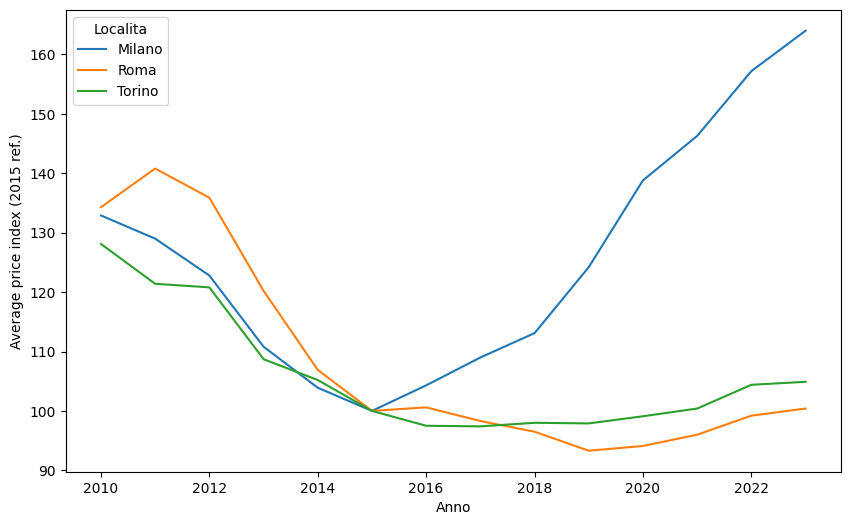

In [17]:
# Grouping the data by the 'names' column
grouped = house_df.groupby("ITTER107")
plt.figure(figsize=(10, 6))

for name, group in grouped:
    plt.plot(group["TIME_PERIOD"], group["OBS_VALUE"], label=name)


plt.xlabel('Anno')  
plt.ylabel('Average price index (2015 ref.)') 
plt.legend(title="Localita")  

# Show plot
plt.show()

### Wages

In [31]:
ds_w = discovery.DataSet(dataflow_identifier="155_358")

In [32]:
ds_w.dimensions_info()

,dimension,dimension_ID,description
0,FREQ,CL_FREQ,Frequency
1,ATECO_2007,CL_ATECO_2007,Nace 2007
2,ADJUSTMENT,CL_CORREZ,Adjustment
3,ITTER107,CL_ITTER107,Territory
4,QUAL_PROF,CL_PROFILO_PROF,Professional status detailed
5,TIP_AGGR1,CL_TIPO_DATO7,Data type 7


In [33]:
ds_w.get_dimension_values("ITTER107")

,values_ids,values_description
0,IT,Italy
